In [1]:
import pandas as pd
from pandas.api.types import is_float_dtype, is_integer_dtype
import numpy as np
import os
import masking_effects_on_xai_techniques.hierarchies as hi
import textwrap

from sklearn.preprocessing import LabelEncoder
from anjana.anonymity import (
    k_anonymity_inner,
    k_anonymity,
    l_diversity,
    t_closeness,
    alpha_k_anonymity,
)

from masking_effects_on_xai_techniques import finding_k
from masking_effects_on_xai_techniques import anonymized_preprocessor as anon_prep
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTENC, SMOTE, RandomOverSampler

In [2]:
def create_disease_encoding(df):
    features = ["Hinselmann", "Schiller", "Citology", "Biopsy"]

    df[features] = df[features].astype(int)

    df["disease"] = (
        (df["Hinselmann"] * 8)
        + (df["Schiller"] * 4)
        + (df["Citology"] * 2)
        + (df["Biopsy"] * 1)
    )

    mapping = {}

    for encoding_value in range(16):
        binary_string = format(encoding_value, "04b")

        combination = tuple(int(bit) for bit in binary_string)
        combination_str = ""
        for i, feat in enumerate(features):
            if combination[i] == 1:
                combination_str += f"{feat}, "

        if combination_str:
            combination_str = combination_str[:-2]
        else:
            combination_str = "No Disease"

        mapping[encoding_value] = combination_str

    return df, mapping

In [3]:
os.chdir("..")
pd.set_option("display.max_columns", None)

# Preprocessing

In [31]:
df = pd.read_csv("./data/cervic_cancer/data.csv")
df = df.replace("?", np.nan)

# Convert target features to one feature
target_features = ["Hinselmann", "Schiller", "Citology", "Biopsy"]
df, disease_map = create_disease_encoding(df)
target_df = df[target_features]
df = df.drop(target_features, axis=1)

# Drop other tagert features
df = df.drop(["Dx:Cancer", "Dx:CIN", "Dx:HPV", "Dx"], axis=1)

df.columns = df.columns.str.replace(")", "_", regex=False)
df.columns = df.columns.str.replace("(", "_", regex=False)
df.columns = df.columns.str.replace("/", "-", regex=False)

In [32]:
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes _years_,Smokes _packs-year_,Hormonal Contraceptives,Hormonal Contraceptives _years_,IUD,IUD _years_,STDs,STDs _number_,STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,disease
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,2
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0


## NaN Values
The dataset has a lot of NaN values. We now consider those

In [33]:
print(f"{'Feature':.<{40}} # NoN Null Frac")
for feat in df.columns:
    non_null = df[feat].notnull().sum()
    frac = round(non_null / df.shape[0] * 100, 1)

    print(f"{feat:.<{40}} {non_null:<{10}} {frac}")

Feature................................. # NoN Null Frac
Age..................................... 858        100.0
Number of sexual partners............... 832        97.0
First sexual intercourse................ 851        99.2
Num of pregnancies...................... 802        93.5
Smokes.................................. 845        98.5
Smokes _years_.......................... 845        98.5
Smokes _packs-year_..................... 845        98.5
Hormonal Contraceptives................. 750        87.4
Hormonal Contraceptives _years_......... 750        87.4
IUD..................................... 741        86.4
IUD _years_............................. 741        86.4
STDs.................................... 753        87.8
STDs _number_........................... 753        87.8
STDs:condylomatosis..................... 753        87.8
STDs:cervical condylomatosis............ 753        87.8
STDs:vaginal condylomatosis............. 753        87.8
STDs:vulvo-perineal condylomat

We drop all rows that has under 33% NaN values  

Below we fil nan with mean or median depending on the datatype. If feature is whole number (likely a category) it is the median, otherwise it is the mean

In [34]:
frac_nan = 0.33
# Convert to Numeric
for feat in df.columns:
    col = pd.to_numeric(df[feat])
    non_nan = col.dropna()
    frac_non_nan = len(non_nan.dropna()) / len(col)
    if frac_non_nan < frac_nan:
        df = df.drop([feat], axis=1)
        continue

    is_whole_number = np.all(np.isclose(non_nan, non_nan.round()))
    if is_whole_number:
        col = col.fillna(col.median())
    else:
        col = col.fillna(col.mean())
    df[feat] = col

In [35]:
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes _years_,Smokes _packs-year_,Hormonal Contraceptives,Hormonal Contraceptives _years_,IUD,IUD _years_,STDs,STDs _number_,STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,disease
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [36]:
df.nunique()

Age                                   44
Number of sexual partners             12
First sexual intercourse              21
Num of pregnancies                    11
Smokes                                 2
Smokes _years_                        31
Smokes _packs-year_                   63
Hormonal Contraceptives                2
Hormonal Contraceptives _years_       41
IUD                                    2
IUD _years_                           27
STDs                                   2
STDs _number_                          5
STDs:condylomatosis                    2
STDs:cervical condylomatosis           1
STDs:vaginal condylomatosis            2
STDs:vulvo-perineal condylomatosis     2
STDs:syphilis                          2
STDs:pelvic inflammatory disease       2
STDs:genital herpes                    2
STDs:molluscum contagiosum             2
STDs:AIDS                              1
STDs:HIV                               2
STDs:Hepatitis B                       2
STDs:HPV        

The fact that HIV and the other long thing only has one kind of events, is because no one has it. These do not add anything to the model, since they are identical for all instances, and therefore they are dropped.

In [37]:
df = df.drop(["STDs:AIDS", "STDs:cervical condylomatosis"], axis=1)

# Fixing Imabalance
We want to fix the imbalance of the dataset. Over-sampling did not prove that usefull, and under-sampling the majority class is not sufficient either. We have chosen a hybrid approach. We undersample the majority class, merge the most uncommon target classes such that each target class has at least 12 instances, and then we over-sample to fix the imbalance of the dataset. 

In [38]:
df["disease"].value_counts()

disease
0     756
2      20
13     19
4      14
5      12
7      11
12      6
15      6
1       6
14      3
6       3
8       1
3       1
Name: count, dtype: int64

To use SMOTE, we must have enough instances per class. We therefore remove 14, 6, 8, 3.

In [39]:
df = df[~df["disease"].isin([14, 6, 8, 3])]

In [40]:
# Try to undersample majority instances
majority = df[df["disease"] == 0]
indices_to_drop = majority.sample(n=500, random_state=42).index

df = df.drop(indices_to_drop, axis=0)
# This seemed to imporove the accuracy by a LOT. The resulting accuracy increase as more is generalized,
# but that might be because of the curse of high dimensionality.

In [41]:
le = LabelEncoder()

df["disease"] = le.fit_transform(df["disease"])

for i, class_label in enumerate(le.classes_):
    print(f"Original: {class_label} -> Encoded: {i}")

Original: 0 -> Encoded: 0
Original: 1 -> Encoded: 1
Original: 2 -> Encoded: 2
Original: 4 -> Encoded: 3
Original: 5 -> Encoded: 4
Original: 7 -> Encoded: 5
Original: 12 -> Encoded: 6
Original: 13 -> Encoded: 7
Original: 15 -> Encoded: 8


Need to define what features are categorical, e.g. can only be whole numbers.

In [42]:
[(i, feat) for i, feat in enumerate(df.columns)]

[(0, 'Age'),
 (1, 'Number of sexual partners'),
 (2, 'First sexual intercourse'),
 (3, 'Num of pregnancies'),
 (4, 'Smokes'),
 (5, 'Smokes _years_'),
 (6, 'Smokes _packs-year_'),
 (7, 'Hormonal Contraceptives'),
 (8, 'Hormonal Contraceptives _years_'),
 (9, 'IUD'),
 (10, 'IUD _years_'),
 (11, 'STDs'),
 (12, 'STDs _number_'),
 (13, 'STDs:condylomatosis'),
 (14, 'STDs:vaginal condylomatosis'),
 (15, 'STDs:vulvo-perineal condylomatosis'),
 (16, 'STDs:syphilis'),
 (17, 'STDs:pelvic inflammatory disease'),
 (18, 'STDs:genital herpes'),
 (19, 'STDs:molluscum contagiosum'),
 (20, 'STDs:HIV'),
 (21, 'STDs:Hepatitis B'),
 (22, 'STDs:HPV'),
 (23, 'STDs: Number of diagnosis'),
 (24, 'disease')]

In [72]:
cat_i = [i for i in range(len(df.columns) - 1)]
num_i = [0, 5, 6, 8]
for i in num_i:
    cat_i.remove(i)

In [44]:
X = df.drop("disease", axis=1)
y = df["disease"]
X_resampled, y_resampled = SMOTENC(
    random_state=0, categorical_features=cat_i
).fit_resample(X, y)
# X_resampled, y_resampled = SMOTE(random_state=0).fit_resample(X, y)
y_resampled.name = "disease"
df = pd.concat([X_resampled, y_resampled], axis=1)

In [45]:
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes _years_,Smokes _packs-year_,Hormonal Contraceptives,Hormonal Contraceptives _years_,IUD,IUD _years_,STDs,STDs _number_,STDs:condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,disease
0,15,1.0,14.0,1.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,46,3.0,21.0,4.0,0.0,0.000000,0.000000,1.0,15.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,51,3.0,17.0,6.0,1.0,34.000000,3.400000,0.0,0.000000,1.0,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,7
3,44,3.0,15.0,2.0,1.0,1.266973,2.800000,0.0,0.000000,0.0,0.514804,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,43,2.0,18.0,5.0,0.0,0.000000,0.000000,0.0,0.000000,1.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2299,29,3.0,18.0,1.0,0.0,6.872082,6.872082,1.0,6.457292,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8
2300,30,3.0,18.0,2.0,0.0,0.000000,0.000000,1.0,9.864762,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8
2301,36,3.0,18.0,2.0,0.0,0.000000,0.000000,1.0,13.734944,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8
2302,30,3.0,18.0,2.0,0.0,0.000000,0.000000,1.0,9.141648,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8


# Defining Hierarchies
We not want to create taxonomies for each feature  
The idea is simple. All features with two or less number of values are considered binary. Simple taxonomy trees for those are generated. They are already at their highest generalization level, so the only thing to do is to suppress them completely once they get generalized once.  
For numeric features we can use our normal approaches

In [46]:
# Find binary features
bin_feat = []
num_feat = []
for feat, n in zip(df.columns, df.nunique()):
    if n == 2:
        bin_feat.append(feat)
    else:
        num_feat.append(feat)

## Binary Features

In [47]:
for feat in bin_feat:
    print(f"{feat:.<{40}} {df[feat].mean()}")
    # print(f"{df[feat].value_counts(normalize=True)}")

Smokes.................................. 0.026041666666666668
Hormonal Contraceptives................. 0.7083333333333334
IUD..................................... 0.06380208333333333
STDs.................................... 0.028645833333333332
STDs:condylomatosis..................... 0.011284722222222222
STDs:vaginal condylomatosis............. 0.00043402777777777775
STDs:vulvo-perineal condylomatosis...... 0.011284722222222222
STDs:syphilis........................... 0.003472222222222222
STDs:genital herpes..................... 0.00043402777777777775
STDs:molluscum contagiosum.............. 0.00043402777777777775
STDs:HIV................................ 0.00390625
STDs:HPV................................ 0.0008680555555555555


This might be a problem. Some of these are very skewed, making anonymization difficult

In [48]:
# Write simple taxonomies to hierarchies
hierarchies_path = "./hierarchies/cervic_cancer"
for feat in bin_feat:
    with open(f"{hierarchies_path}/{feat}.csv", "w") as f:
        for val in df[feat].unique():
            f.write(f"{val}, *\n")

## Numeric Features

In [49]:
def create_and_save(feat, n):
    hiear = hi.generate_qcut_hierarchy(df[feat], n, search_for_n=True)
    hi.save_hierarchy(hiear, f"{hierarchies_path}/{feat}.csv")

In [50]:
for feat in num_feat:
    try:
        create_and_save(feat, 3)
        # print(f"Generated hierarchy for {feat}")
    except RuntimeError:
        if df[feat].nunique() == 1:
            print(f"{feat}, only has one value. Removing feature")
            df = df.drop(feat, axis=1)
        else:
            print("failed for " + feat)

/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/p

STDs:pelvic inflammatory disease, only has one value. Removing feature
STDs:Hepatitis B, only has one value. Removing feature


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)


Semantically, some of these might not make sense. The number of pregnancies a person can have can be between 0.8 and 2,4.  
The algorithm failed to generate hierarchies for two features. We consider those by hand

This feature is so skewed, that it is almost impossible to generalize meaningfully with a taxonomy tree. Even if we split it so all 0 are together and everything else is together, only 7% would be in the non-zero categoy. For now we try and create it by hand, but it might turn out bad when we anonymize

## Old code defining hiearchies by hand for failed generations

with open(f"{hierarchies_path}/{feat}.csv", "w") as f:
    content = textwrap.dedent(
        """
0.0, "(-0.001, 1.0]",*
1.0, "(1.0, 5.0]",*
2.0, "(1.0, 5.0]",*
3.0, "(1.0, 5.0]",*
4.0, "(1.0, 5.0]",*
"""
    ).strip()

    f.write(content + "\n")

feat = "STDs: Number of diagnosis"
df[feat].value_counts()

Same story

with open(f"{hierarchies_path}/{feat}.csv", "w") as f:
    content = textwrap.dedent(
        """
0, "(-0.001, 1.0]",*
1, "(1.0, 3.0]",*
2, "(1.0, 3.0]",*
3, "(1.0, 3.0]",*
"""
    ).strip()

    f.write(content + "\n")

# Anonymization

In [51]:
hierarchies = {}
for feat in df.columns:
    hierarchies[feat] = dict(pd.read_csv(f"{hierarchies_path}/{feat}.csv", header=None))

In [52]:
quasi_ident = list(df.columns)
quasi_ident.remove("disease")

ident = []
sens_att = "disease"

In [53]:
all_counts_and_features = []
for feat, items in hierarchies.items():
    for item in items.values():
        length = len(item.unique())
        all_counts_and_features.append((length, feat))
sorted_data = sorted(all_counts_and_features, key=lambda x: x[0], reverse=True)
ordered_features = [feat for count, feat in sorted_data]

for feat, items in hierarchies.items():
    lengths = [f"{len(item.unique()):>4}" for item in items.values()]
    out = ", ".join(lengths)
    print(f"{feat:<15}: {out}")

print("Order in which features will be generalized:")
print(ordered_features)

Age            :   51,    3,    2,    1
Number of sexual partners:    8,    3,    2,    1
First sexual intercourse:   18,    3,    2,    1
Num of pregnancies:   10,    3,    2,    1
Smokes         :    2,    1
Smokes _years_ :  736,    3,    2,    1
Smokes _packs-year_:  750,    3,    2,    1
Hormonal Contraceptives:    2,    1
Hormonal Contraceptives _years_: 1646,    3,    2,    1
IUD            :    2,    1
IUD _years_    :   18,    3,    2,    1
STDs           :    2,    1
STDs _number_  :    5,    3,    2,    1
STDs:condylomatosis:    2,    1
STDs:vaginal condylomatosis:    2,    1
STDs:vulvo-perineal condylomatosis:    2,    1
STDs:syphilis  :    2,    1
STDs:genital herpes:    2,    1
STDs:molluscum contagiosum:    2,    1
STDs:HIV       :    2,    1
STDs:HPV       :    2,    1
STDs: Number of diagnosis:    4,    3,    2,    1
disease        :    9,    3,    2,    1
Order in which features will be generalized:
['Hormonal Contraceptives _years_', 'Smokes _packs-year_', 'Smokes _y

In [54]:
%%time
# Check with mina if this k is representative of used k in litterature
k = 20
supp_level = 10  # Select the suppression limit allowed
anon_df, supp_n, hiear = k_anonymity_inner(
    df, ident, quasi_ident, k, supp_level, hierarchies
)
max_supp_n = int(round(len(df) * supp_level / 100, 0))
print(f"Max rows that can be suppressed: {max_supp_n}")
print(f"Rows suppressed                : {supp_n}")
print(f"% of allowed rows suppressed   : {round(supp_n / max_supp_n * 100, 1)}%")
print(f"Generalization level           : {sum(hiear.values())}")
hiear

Max rows that can be suppressed: 230
Rows suppressed                : 209
% of allowed rows suppressed   : 90.9%
Generalization level           : 20
CPU times: user 698 ms, sys: 12.9 ms, total: 711 ms
Wall time: 726 ms


{'Age': 2,
 'Number of sexual partners': 2,
 'First sexual intercourse': 2,
 'Num of pregnancies': 2,
 'Smokes': 0,
 'Smokes _years_': 2,
 'Smokes _packs-year_': 2,
 'Hormonal Contraceptives': 0,
 'Hormonal Contraceptives _years_': 2,
 'IUD': 0,
 'IUD _years_': 2,
 'STDs': 0,
 'STDs _number_': 2,
 'STDs:condylomatosis': 0,
 'STDs:vaginal condylomatosis': 0,
 'STDs:vulvo-perineal condylomatosis': 0,
 'STDs:syphilis': 0,
 'STDs:genital herpes': 0,
 'STDs:molluscum contagiosum': 0,
 'STDs:HIV': 0,
 'STDs:HPV': 0,
 'STDs: Number of diagnosis': 2}

In [55]:
anon_df

,index,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes _years_,Smokes _packs-year_,Hormonal Contraceptives,Hormonal Contraceptives _years_,IUD,IUD _years_,STDs,STDs _number_,STDs:condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:genital herpes,STDs:molluscum contagiosum,STDs:HIV,STDs:HPV,STDs: Number of diagnosis,disease
0,0,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",0.0,"(-0.001, 1.269]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",0
1,1,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",0
2,5,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",0
3,8,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",7
4,9,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090,2299,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(2.62, 34.0]","(0.762, 21.0]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",8
2091,2300,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",8
2092,2301,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",8
2093,2302,"(13.999, 39.0]","(0.999, 4.5]","(9.999, 18.5]","(-0.001, 4.5]",0.0,"(-0.001, 2.62]","(-0.001, 0.762]",1.0,"(1.269, 30.0]",0.0,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(-0.001, 1.5]",8


Note how all features from left to right slowly get suppressed. The anonymization algorithm probably generalizes all features until they all become binary. Then it probably anonymizes the features in the order they appear in `df.columns`. 

# Finding K

In [56]:
k_list = [2**n for n in range(1, 9)]
anon_data = finding_k.generate_k_anonymity_data(
    df, 20, ident, quasi_ident, hierarchies, k_list
)

Anonymizing for k=2
Anonymizing for k=4
Anonymizing for k=8
Anonymizing for k=16
Anonymizing for k=32
Anonymizing for k=64
Anonymizing for k=128
Anonymizing for k=256
Done anonymizing


In [57]:
models, scores = finding_k.train_models(anon_data, "disease", hierarchies_path)

/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


0.5954301075268817


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


0.5518134715025906


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


0.4330708661417323


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


0.2622739018087855
0.2653333333333333
0.2449255751014885
0.25092707045735474
0.25092707045735474


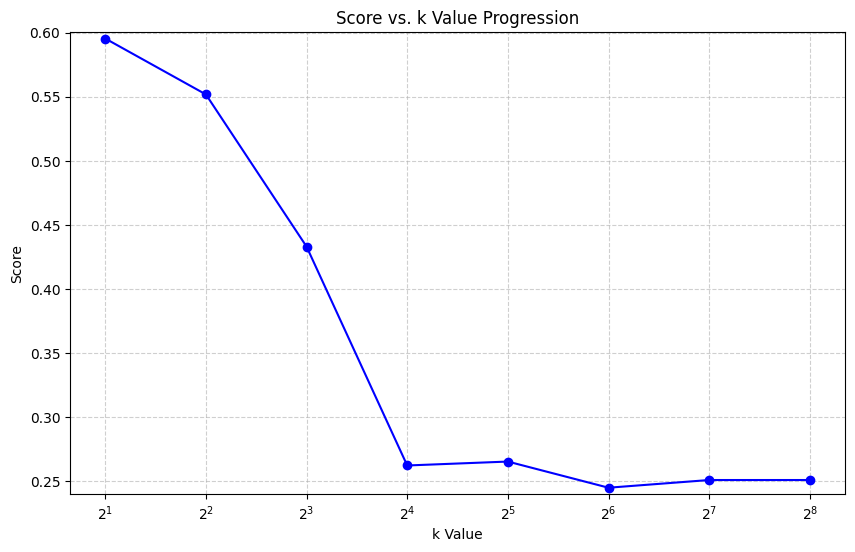

In [58]:
finding_k.plot_k_vs_score(scores, k_list)

This is respectable. A k of 4 will be used since it does not anonymize the data too much and the accuracy is fine

In [62]:
df.to_csv("./data/cervic_cancer/clean.csv", index=False)